### Agent Architecture

So an agentic LLM application must be one that uses an LLM to pick from one or more possible courses of action, given some context about the current state of the world or some desired next state. These attributes are usually implemented by mixing two prompting techniques we first met in the Preface:

Tool calling
Include a list of external functions that the LLM can make use of in your prompt (that is, the actions it can decide to take) and provide instructions on how to format its choice in the output it generates. You’ll see in a moment what this looks like in the prompt.

Chain-of-thought
Researchers have found that LLMs “make better decisions” when given instructions to reason about complex problems by breaking them down into granular steps to be taken in sequence. This is usually done either by adding instructions along the lines of “think step by step” or including examples of questions and their decomposition into several steps/actions.

In [5]:
from dotenv import load_dotenv
import os
load_dotenv()
GoogleGeminiKey = os.getenv('GOOGLE_GEMINI_KEY')
mc_token = os.getenv('MC_TOKEN')


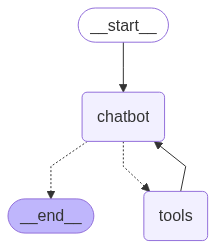

In [3]:
import ast
from typing import Annotated, TypedDict

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI

from langgraph.graph import START,StateGraph,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

@tool
def calculator(query: str) -> str:
    """A simple calculator tool that can perform basic arithmetic operations."""
    return ast.literal_eval(query)

search = DuckDuckGoSearchRun()
tools = [calculator, search]

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001",api_key=GoogleGeminiKey, temperature=0.1).bind_tools(tools)

class State(TypedDict):
    messages:Annotated[list,add_messages]
    # tools: Annotated[list[ToolNode],tools_condition]
    # state_graph: Annotated[StateGraph,START]

def chatbot(state:State) -> State:
    res = model.invoke(state["messages"])
    return {"messages":res}


builder = StateGraph(State)
builder.add_node("chatbot",chatbot)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,"chatbot")
builder.add_conditional_edges("chatbot",tools_condition)
builder.add_edge("tools","chatbot")

graph = builder.compile()
graph



In [10]:
from langchain_core.messages import HumanMessage
input = {
    "messages": [
        HumanMessage("""who is current president of united states?""")
    ]
}
for c in graph.stream(input):
    print(c)

{'chatbot': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "current president of united states"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--81770e40-66be-4476-becd-ac981a96b24c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'current president of united states'}, 'id': '1a3c03b5-4eb0-43db-8538-fc9e8dd2894d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 65, 'output_tokens': 11, 'total_tokens': 76, 'input_token_details': {'cache_read': 0}})}}


f:\miniconda\envs\vlang\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'tools': {'messages': [ToolMessage(content="Jan 20, 2025 · Donald Trump, who overcame impeachments, criminal indictments and a pair of assassination attempts to win another term in the White House, was sworn in Monday as the 47th U.S. president taking... Jan 20, 2025 · Donald Trump has officially become the 47th president of the United States. In a special ceremony called an inauguration, President Trump took over from Joe Biden as America's new leader. A... Mar 5, 2025 · Learn about the duties of president, vice president, and first lady of the United States. Find out how to contact and … Apr 15, 2025 · Donald J. Trump is the President of the USA in 2025 after a landslide re-election victory. Explore his achievements, policies, … On January 20, 2025, Donald Trump was sworn in as the 47th President of the United States. He is only the second President to serve non- consecutive terms since Grover Cleveland in 1893. At 78 years and seven months old, Mr. Trump is also the oldest presiden

### Always Calling a Tool First
In the standard agent architecture, the LLM is always called upon to decide what tool to call next. This arrangement has a clear advantage: it gives the LLM ultimate flexibility to adapt the behavior of the application to each user query that comes in. But this flexibility comes at a cost: unpredictability. If, for instance, you, the developer of the application, know that the search tool should always be called first, that can actually be beneficial to your application:

It will reduce overall latency, as it will skip the first LLM call that would generate that request to call the search tool.

It will prevent the LLM from erroneously deciding it doesn’t need to call the search tool for some user queries.

On the other hand, if your application doesn’t have a clear rule of the kind “you should always call this tool first,” introducing such a constraint would actually make your application worse.

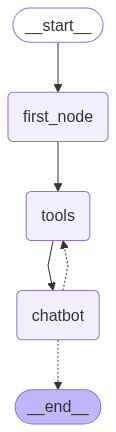

In [13]:
import uuid
from langchain_core.messages import AIMessage, HumanMessage,ToolCall


def first_node(state:State) -> State:
    query = state['messages'][-1].content
    search_tool_call = ToolCall(name="duckduckgo_search", args={"query": query},id=uuid.uuid4().hex)


    return {"messages":AIMessage(content="",tool_calls=[search_tool_call])}


builder = StateGraph(State)
builder.add_node("first_node", first_node)
builder.add_node("chatbot",chatbot)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"first_node")
builder.add_edge("first_node","tools")
builder.add_conditional_edges("chatbot",tools_condition)
builder.add_edge("tools","chatbot")
graph =builder.compile()
graph

In [14]:
from langchain_core.messages import HumanMessage
input = {
    "messages": [
        HumanMessage("""who is current president of united states?""")
    ]
}
for c in graph.stream(input):
    print(c)

{'first_node': {'messages': AIMessage(content='', additional_kwargs={}, response_metadata={}, id='2ec54e75-07a8-4ed8-8253-b2eb8a35db44', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'who is current president of united states?'}, 'id': '89c0a6afc0ef4e728a33b9eff46a0e4a', 'type': 'tool_call'}])}}


f:\miniconda\envs\vlang\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'tools': {'messages': [ToolMessage(content='48 rows · The president of the United States is the head of state and head of government of the United States, [1] indirectly elected … Jan 20, 2025 · Donald Trump has officially become the 47th president of the United States. In a special ceremony called an … Apr 15, 2025 · As of 2025, the President of the United States is Donald J. Trump, a real estate mogul, television personality, and … Mar 5, 2025 · Learn about the duties of president, vice president, and first lady of the United States. Find out how to … Jan 20, 2025 · Donald Trump, who overcame impeachments, criminal indictments and a pair of assassination …', name='duckduckgo_search', id='5f9bdfc1-38a8-4508-8d26-c08fdd2a183b', tool_call_id='89c0a6afc0ef4e728a33b9eff46a0e4a')]}}
{'chatbot': {'messages': AIMessage(content='Based on the search results, the current president of the United States is Donald Trump.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason

#### Multiples tools can lost context

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
from typing import Literal, Optional
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



mc_common_headers = { 
        "accept": "application/json",
        "origin": "https://www.moneycontrol.com",
        "referer": "https://www.moneycontrol.com/",
        "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36",
        "auth-token": mc_token,
    }

@tool
def nse_heatmap(
    period: Literal["1D", "5D", "1M", "3M", "6M", "1Y", "3Y", "5Y"] = "5D",
    type_: Literal["EW", "MW", "VW"] = "EW",
    indexId: int = 9,
    subType: Optional[str] = "ST"
) -> dict:
    """
    Fetches the heat map data for a specified index from MoneyControl's API.

    This data provides a snapshot of the top movers in a specific market index over a selected period.
    Each company includes change %, LTP, market cap, sector, and other relevant analytics useful in
    stock/sector performance analysis.

    Args:
        period (str): Time period for the data. Options include:
                      - "1D" for 1 Day
                      - "5D" for 5 Days
                      - "1M" for 1 Month
                      - "3M" for 3 Months
                      - "6M" for 6 Months
                      - "1Y" for 1 Year
                      - "3Y" for 3 Years
                      - "5Y" for 5 Years
                      Default is "5D".
        
        type_ (str): Weighting type for the index calculation.
                     - "EW" for Equal Weight
                     - "MW" for Market Cap Weight
                     - "VW" for Volume Weight
                     Default is "EW".

        indexId (int): ID of the index to fetch data for. Example:
                       - 9 corresponds to Nifty 50.
                       - Other IDs may correspond to sectoral or thematic indices.
        
        subType (str, optional): Subtype of the index. Default is "ST".

    Returns:
        dict: Dictionary containing success flag and list of constituent stock data with keys:
              - fullName: Full name of the company
              - name: Stock symbol
              - ltp: Last traded price
              - change: Absolute price change
              - changeP: Percentage price change
              - url: MoneyControl page URL for the stock
              - color: Visual cue for gain/loss
              - mrkCap: Market capitalization
              - sector: Sector to which the company belongs
              - value: Same as percentage change
              - scId: Stock code
    """

    url = "https://api.moneycontrol.com/mcapi/v1/indices/ad-ratio/heat-map"
    params = {
        "period": period,
        "type": type_,
        "indexId": indexId,
        "subType": subType
    }

    response = requests.get(url, params=params, headers=mc_common_headers)
    response.raise_for_status()

    return response.json()['data']


@tool
def get_economic_indicators(
    country: str = "India",
    category: str = "Major Indicators"
) -> dict:
    """
    Fetches major economic indicators for a specific country from MoneyControl's economic calendar API.

    This data includes key macroeconomic metrics like GDP growth, interest rate, inflation, etc.
    Each entry includes metadata such as last/previous value, date, symbol, and historical trend.

    Args:
        country (str): Country for which to retrieve indicators (e.g., "India","United States","China","Euro Area").
        category (str): Indicator category (Major Indicators,GDP,Labour,Government,Prices,Money,Trade,Business,Housing,Taxes,Consumer,Climate,Health).

    Returns:
        dict: A dictionary with:
            - tableHeaders: List of column metadata with name and type.
            - tableData: List of records, each with:
                - indicator name
                - country
                - values (last, previous)
                - date, unit
                - symbol
                - trend (historical time series as list of date-value pairs)

    Raises:
        Exception: If the request fails or returns non-JSON content.
    """

    url = "https://api.moneycontrol.com/mcapi/v1/ecalendar/get-indicator-details"
    params = {
        "country": country,
        "category": category
    }

    response = requests.get(url, params=params, headers=mc_common_headers)

    if response.status_code != 200:
        raise Exception(f"Error: Received status code {response.status_code} - {response.reason}")

    try:
        return response.json()['data']
    except requests.exceptions.JSONDecodeError:
        print("Raw response content (truncated):", response.text[:500])
        raise Exception("Failed to decode JSON. Check if the response content is valid.")


@tool
def nse_sector_trends(
    dur: Literal["1d", "5d", "1m", "3m", "6m", "1y"] = "5d",
    section:Literal["industry", "sector"] = "sector",
) -> dict:
    """
    Fetches market trend and capitalization data across all sectors from MoneyControl.

    This data provides insight into sector-level performance over a given duration, 
    including market cap changes, number of advancing/declining stocks, P/E ratio, 
    net profit YoY, and sector trend (bullish/neutral/bearish).

    Args:
        dur (str): Time duration to analyze sector performance over.
                   Accepted values: "1d", "5d", "1m", "3m", "6m", "1y". Default is "5d".

    Returns:
        list[dict]: A list of sectors with each containing:
            - sector (str): Sector name
            - trend (str): "Bullish", "Neutral", or "Bearish"
            - stockCnt (int): Number of stocks in the sector
            - industryCnt (int): Number of industries
            - advance (int): Stocks that advanced
            - decline (int): Stocks that declined
            - currentMcap (str): Market cap in ₹ Cr
            - mCapPerChange (float): % change in market cap
            - mCapChange (str): Absolute change in market cap
            - sectorPe (str): Sector's average P/E ratio
            - sectorNpYoy (str): Net profit YoY (₹ Cr)
            - sectorNpYoyChange (float): YoY % change
            - slug (str): SEO-friendly identifier for the sector

    Raises:
        Exception: If the API request fails or returns invalid JSON.
    """

    url = "https://api.moneycontrol.com/mcapi/v1/sector/listing"
    params = {
        "dur": dur,
        "section": "sector"
    }

    response = requests.get(url, params=params, headers=mc_common_headers)

    if response.status_code != 200:
        raise Exception(f"Error: Received status code {response.status_code} - {response.reason}")

    try:
        return response.json()['data']
    except requests.exceptions.JSONDecodeError:
        print("Raw response content (truncated):", response.text[:500])
        raise Exception("Failed to decode JSON. Response may be malformed or blocked.")  

@tool
def visualize_stock_heatmap(data: dict, top_n: int = 20):
    """
    Visualize top stock movers in a heatmap based on percentage change.

    Args:
        data (dict): JSON response from `get_moneycontrol_heatmap`.
        top_n (int): Number of top movers to display. Default: 20.
    """
    df = pd.DataFrame(data["chartData"])
    df = df.sort_values("changeP", ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        y="name", x="changeP", data=df,
        palette=["#46D67A" if x > 0 else "#FF4C4C" for x in df["changeP"]]
    )
    plt.title(f"Top {top_n} Stock Movers by % Change")
    plt.xlabel("% Change")
    plt.ylabel("Stock Symbol")
    plt.grid(True, axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()   

@tool
def plot_economic_indicators_grid(data: dict):
    """
    Plots each economic indicator in a separate subplot using Seaborn's FacetGrid.
    
    Args:
        data (dict): JSON response from get_moneycontrol_economic_indicators()
    """
    all_trends = []

    for row in data["tableData"]:
        indicator = row[1]
        trend_data = row[-1]

        if not trend_data:
            continue

        for point in trend_data:
            all_trends.append({
                "indicator": indicator,
                "date": pd.to_datetime(point["date"]),
                "value": point["value"]
            })

    df = pd.DataFrame(all_trends)
    df = df.sort_values("date")

    # Plot using FacetGrid
    g = sns.FacetGrid(df, col="indicator", col_wrap=4, sharey=False, height=3.5)
    g.map_dataframe(sns.lineplot, x="date", y="value", marker="o")
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Date", "Value")
    g.fig.suptitle("Economic Indicators Grid Plot", fontsize=16)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.93)  # Adjust to not overlap title
    plt.show()

@tool
def visualize_sector_performance(data: list[dict], top_n: int = 10):
    """
    Visualize top sectors by market cap % change.

    Args:
        data (list): Response from `get_moneycontrol_sector_trends`.
        top_n (int): Number of sectors to display.
    """
    df = pd.DataFrame(data)
    df = df.sort_values("mCapPerChange", ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        y="sector", x="mCapPerChange", data=df,
        palette=["#46D67A" if x > 0 else "#FF4C4C" for x in df["mCapPerChange"]]
    )
    plt.title(f"Top {top_n} Sectors by Market Cap % Change")
    plt.xlabel("% Market Cap Change")
    plt.ylabel("Sector")
    plt.grid(True, axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()

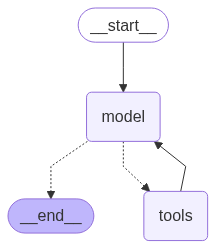

In [83]:
search = DuckDuckGoSearchRun()

tools = [search,visualize_sector_performance,plot_economic_indicators_grid,visualize_stock_heatmap,nse_sector_trends,get_economic_indicators,nse_heatmap]
model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001",api_key=GoogleGeminiKey, temperature=0.1).bind_tools(tools)


def finbot(state:State) -> State:
    res = model.invoke(state["messages"])
    return {"messages":res}

builder = StateGraph(State)
builder.add_node("model",finbot)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"model")
builder.add_conditional_edges("model",tools_condition)
builder.add_edge("tools","model")

graph = builder.compile()
graph



In [84]:
input = {
    "messages":[
        HumanMessage("fetch the major economic indicators of US")
    ]
}

for c in graph.stream(input):
    print(c)

{'model': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_economic_indicators', 'arguments': '{"country": "United States"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--1ea67798-58db-49b0-ae6c-45ab49dff36c-0', tool_calls=[{'name': 'get_economic_indicators', 'args': {'country': 'United States'}, 'id': '173c90b3-9873-49b5-a525-758a3f1f444f', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1264, 'output_tokens': 8, 'total_tokens': 1272, 'input_token_details': {'cache_read': 0}})}}
{'tools': {'messages': [ToolMessage(content='{"tableHeaders": [{"name": "ccId", "type": "int"}, {"name": "indicator", "type": "string"}, {"name": "category", "type": "string"}, {"name": "country", "type": "string"}, {"name": "last", "type": "string"}, {"name": "previous", "type": "string"}, {"name": "unit", "type": "string"}, {"name": "e

In [85]:
input = {
    "messages":[
        HumanMessage("compare the major economic indicators of US and India")
    ]
}

for c in graph.stream(input):
    print(c)

{'model': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_economic_indicators', 'arguments': '{"category": "Major Indicators", "country": "India"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--32e2a5a7-7f85-4203-85d5-ccc45bda6868-0', tool_calls=[{'name': 'get_economic_indicators', 'args': {'country': 'United States', 'category': 'Major Indicators'}, 'id': '7803f503-45f0-4d54-b770-aa7b9c1c868a', 'type': 'tool_call'}, {'name': 'get_economic_indicators', 'args': {'category': 'Major Indicators', 'country': 'India'}, 'id': '611edb00-99b4-4f2a-85da-f41ea69b1cb2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1266, 'output_tokens': 21, 'total_tokens': 1287, 'input_token_details': {'cache_read': 0}})}}
{'tools': {'messages': [ToolMessage(content='{"tableHeaders": [{"name": "ccId", "type": "int"}, {"name": "indicator"

In [86]:
input = {
    "messages":[
        HumanMessage("visualize the major economic indicators of US")
    ]
}

for c in graph.stream(input):
    print(c)

{'model': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_economic_indicators', 'arguments': '{"country": "United States"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--e4900c68-d685-4d7f-beeb-c8e834db3620-0', tool_calls=[{'name': 'get_economic_indicators', 'args': {'country': 'United States'}, 'id': '5ff1adec-5530-42cc-a77a-39cead8ffd42', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1264, 'output_tokens': 8, 'total_tokens': 1272, 'input_token_details': {'cache_read': 0}})}}
{'tools': {'messages': [ToolMessage(content='{"tableHeaders": [{"name": "ccId", "type": "int"}, {"name": "indicator", "type": "string"}, {"name": "category", "type": "string"}, {"name": "country", "type": "string"}, {"name": "last", "type": "string"}, {"name": "previous", "type": "string"}, {"name": "unit", "type": "string"}, {"name": "e

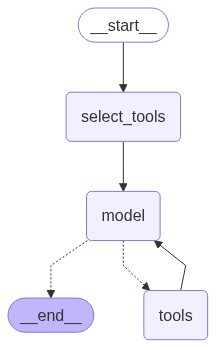

In [25]:

from langchain_community.vectorstores.inmemory import InMemoryVectorStore
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain_core.documents import Document

embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
tools = [visualize_sector_performance,plot_economic_indicators_grid,visualize_stock_heatmap,nse_sector_trends,get_economic_indicators,nse_heatmap]

tool_retriever = InMemoryVectorStore.from_documents(
    [Document(tool.description,metadata={"name": tool.name}) for tool in tools],
embedding=embeddings
).as_retriever()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001")

class State(TypedDict):
    messages: Annotated[list,add_messages]
    selected_tools: list[str]

def model_node(state: State) -> State:
    selected_tools = [tool for tool in tools if tool.name not in state['selected_tools']]
    res = model.bind_tools(selected_tools).invoke(state["messages"])
    return {"messages": res }

def select_tool(state: State) -> State:
    query = state['messages'][-1].content
    tool_docs = tool_retriever.invoke(query)
    return {'selected_tools':[doc.metadata['name'] for doc in tool_docs ]}

builder = StateGraph(State)
builder.add_node("model",model_node)
builder.add_node("select_tools",select_tool)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "select_tools")
builder.add_edge("select_tools","model")
builder.add_conditional_edges("model",tools_condition)
builder.add_edge("tools","model")

graph = builder.compile()
graph

In [11]:
from langchain_core.messages import HumanMessage

input = {
    "messages":[
        HumanMessage("compare the major economic indicators of US and India")
    ]
}

for c in graph.stream(input):
    print(c)

{'select_tools': {'selected_tools': ['calculator', 'duckduckgo_search']}}
{'model': {'messages': AIMessage(content="Okay, let's compare the major economic indicators of the US and India.  This will give us a snapshot of the relative economic health and characteristics of each nation.\n\n**Key Economic Indicators & Comparison:**\n\n| Indicator          | United States (Approximate) | India (Approximate)       | Comparison                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |\n|----------------------|--------------------

In [18]:
print(c['model']['messages'].content)

Okay, let's compare the major economic indicators of the US and India.  This will give us a snapshot of the relative economic health and characteristics of each nation.

**Key Economic Indicators & Comparison:**

| Indicator          | United States (Approximate) | India (Approximate)       | Comparison                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
|----------------------|-----------------------------|---------------------------|-----------------------------------------------------------------------------------

In [26]:
from langchain_core.messages import HumanMessage

input = {
    "messages":[
        HumanMessage("compare the major economic indicators of US and India")
    ]
}

for c in graph.stream(input):
    print(c)

{'select_tools': {'selected_tools': ['get_economic_indicators', 'nse_heatmap', 'plot_economic_indicators_grid', 'nse_sector_trends']}}
{'model': {'messages': AIMessage(content="I'm sorry, I cannot compare the major economic indicators of US and India using the available tools.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--a5f81215-c2d3-485f-a172-8e5b439e7632-0', usage_metadata={'input_tokens': 136, 'output_tokens': 21, 'total_tokens': 157, 'input_token_details': {'cache_read': 0}})}}


In [23]:
print(c['model']['messages'].content)

I am sorry, I cannot fulfill this request. My current capabilities do not allow me to retrieve and compare specific economic indicators between the US and India. However, I can provide a search query that might help you find the information you need.
